# Основные концепции Machine Learning. Домашняя работа

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.cluster import KMeans
import warnings


In [2]:
warnings.filterwarnings("ignore")

In [3]:
#зугружаем данные по телефонам
phones = pd.read_csv('phones_yHVTGz9.csv')
phones.head(7)

,disk,os,price,year
0,64,Android,7256,2016
1,128,Android,7623,2015
2,64,Android,1916,2010
3,512,iOS,15045,2017
4,16,Android,4478,2013
5,512,iOS,15842,2018
6,128,Android,7191,2015


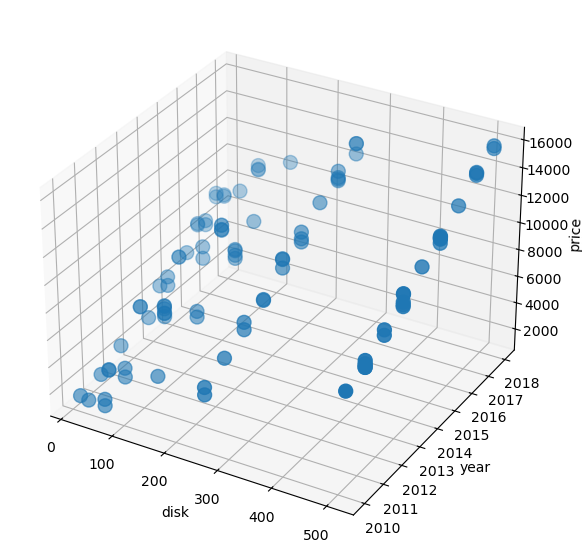

In [11]:
from mpl_toolkits.mplot3d import Axes3D # для отрисовки 3D проекции
fig = plt.figure(figsize=(7, 7)) # создаем картинку
ax = plt.axes(projection="3d") 
# помещаем точки на график
ax.scatter(phones["disk"], phones["year"], phones["price"], s=100)

# называем оси
ax.set_xlabel("disk")
ax.set_ylabel("year")
ax.set_zlabel("price")

# отображаем картинку
plt.show()


Задание 1: обучить модель регрессии

In [12]:
# выгружаем признаки и целевые значения в отдельные переменные
X = phones[["disk", "year"]]
y = phones["price"]

# создаем регрессор
reg = LinearRegression().fit(X, y)

In [13]:
# вытаскиваем нужные коэффициенты
[b1, b2] = reg.coef_
a = reg.intercept_

# создаем функцию для предсказания цены дома
def reg_prediction(disk, year):
    return a + b1 * disk + b2 * year

In [14]:
reg_prediction(X.disk[0], X.year[0])

np.float64(7848.046694419114)

In [15]:
# сделаем предсказания для различных конфигураций домов
d1, d2 = list(), list()
for x in np.linspace(min(phones["disk"]), max(phones["disk"]), 100):
    for y in np.linspace(min(phones["year"]), max(phones["year"]), 100):
        d1.append(x)
        d2.append(y)
d1 = np.array(d1).reshape(-1, 1)
d2 = np.array(d2).reshape(-1, 1)
p = reg.predict(np.concatenate([d1, d2], axis=1))

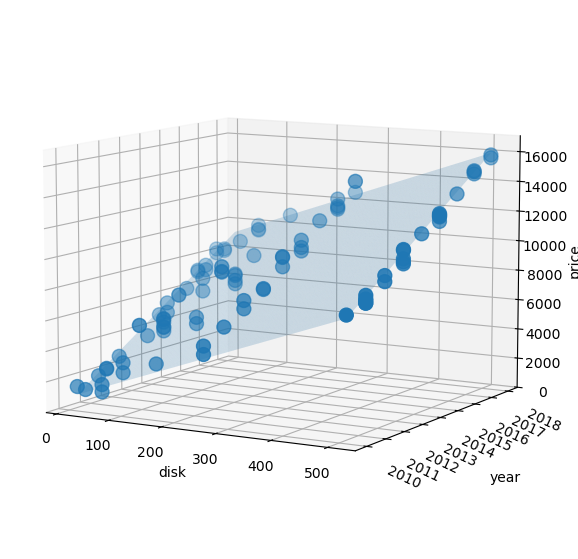

In [41]:
fig = plt.figure(figsize=(7, 7)) # создаем картинку
ax = plt.axes(projection="3d") # устанавливаем проекцию

# помещаем точки на график
ax.scatter(phones["disk"], phones["year"], phones["price"], s=100)

# помещаем предсказанные значения на график
ax.plot_trisurf(d1.ravel(), d2.ravel(), p.ravel(), alpha=0.2)


# называем оси
ax.set_xlabel("disk")
ax.set_ylabel("year", labelpad=20)
ax.set_zlabel("price")
plt.yticks(rotation=-25, ha='left')

# изменяем позицию камеры и отрисовываем картинку
ax.elev = 9
plt.show()

Задание 2: обучить модель классификации

In [38]:
# выгружаем признаки и целевые значения в отдельные переменные
X = phones[["disk", "year"]]
y = phones["os"]

# создаем классификатор
cl = DecisionTreeClassifier().fit(X, y)

In [42]:
# выведем информацию для интерпретации построенной модели
print(export_text(cl))

|--- feature_0 <= 192.00
|   |--- class: Android
|--- feature_0 >  192.00
|   |--- class: iOS



In [57]:
# проведем классификацию
cl.predict(X[10:25])[0], y[1]

('iOS', 'Android')

Задание 3: обучить модель кластеризации

In [48]:
# выгружаем признаки в отдельную переменную
X = phones[["disk", "year"]]

# создаем модель для кластеризации
clust = KMeans(n_clusters=3).fit(X)

In [50]:
# смотрим центры кластеров
[c1, c2, c3] = clust.cluster_centers_
clust.cluster_centers_

array([[ 512.        , 2013.88461538],
       [  57.35849057, 2014.24528302],
       [ 256.        , 2014.57142857]])

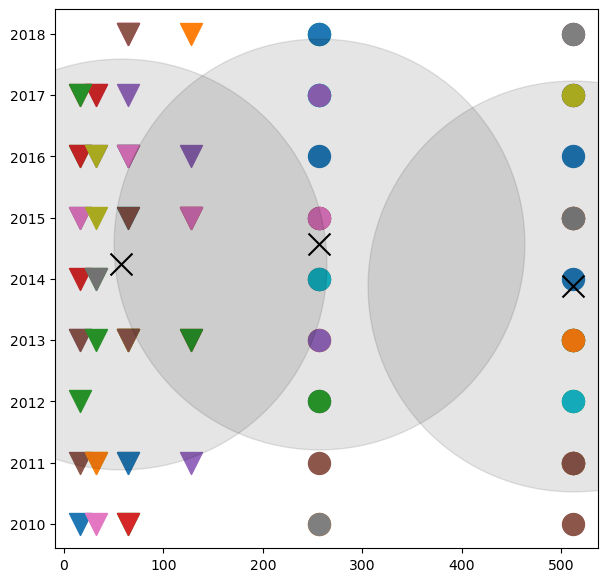

In [59]:
fig = plt.figure(figsize=(7, 7)) # создаем картинку

markers = {"iOS": "o", "Android": "v", "luxury": "*"}
for d1, d2, l in zip(phones.disk, phones.year, phones.os):
    plt.scatter(d1, d2, s=250, marker=markers[l])
    
# добавляем информацию о центрах кластеров
plt.scatter(c1[0], c1[1], s=250, marker="x", c="black")
plt.scatter(c1[0], c1[1], s=250 * 3.5e2, c="black", alpha=0.1)

plt.scatter(c2[0], c2[1], s=250, marker="x", c="black")
plt.scatter(c2[0], c2[1], s=250 * 3.5e2, c="black", alpha=0.1)

plt.scatter(c3[0], c3[1], s=250, marker="x", c="black")
plt.scatter(c3[0], c3[1], s=250 * 3.5e2, c="black", alpha=0.1)

# отображаем картинку
plt.show()